### It improves plain Stochastic Gradient Descent (SGD) by adding memory of past gradients, helping the optimizer move faster and more smoothly toward the minimum.
### SGD with Momentum = SGD + memory of past gradients to move faster and smoother toward the minimum.

### Problem with plain SGD
Issues:

- Oscillates in narrow valleys

- Slow convergence

- Gets affected by noisy gradients

## 2. Idea of Momentum (intuition)

### Think of optimization as rolling a ball down a hill:
 - SGD → ball moves only based on current slope

 - SGD with Momentum → ball gains velocity, so it keeps moving in the same direction and doesn’t stop easily

Momentum accelerates learning in consistent directions and reduces oscillations.

## 3. Mathematical formulation



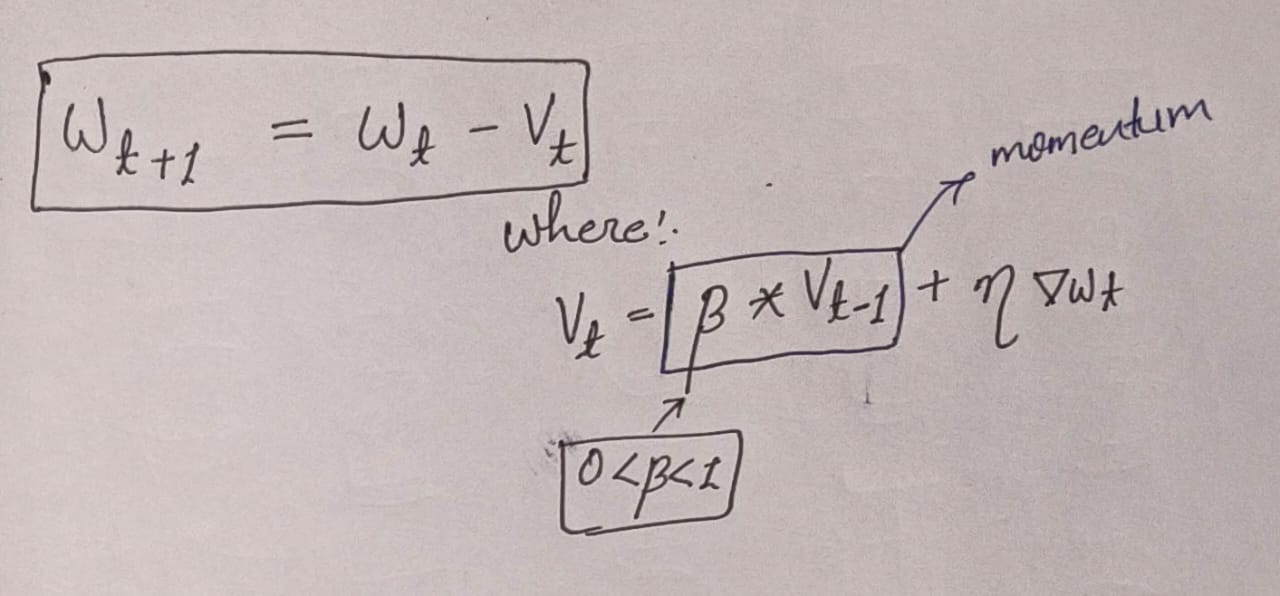

Where:

- 𝑣t = velocity (running average of gradients)

- β = momentum coefficient (usually 0.9)

- η = learning rate

## 4. Effect of beta

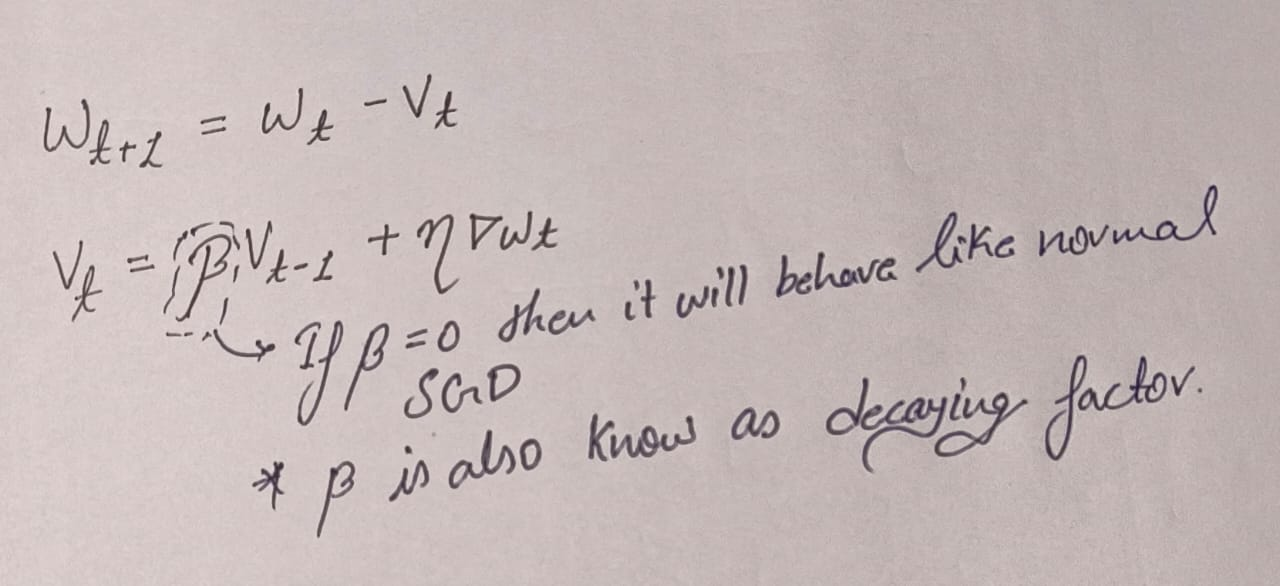

In [25]:
from IPython.display import Image, display

display(Image(url="https://gbhat.com/assets/gifs/sgd_momentum_nesterov.gif"))


## 5. Limitations of SGD with Momentum

1. Sensitive to hyperparameters
2. Can overshoot the minimum
3. Not adaptive to parameter scale
4. Accumulates wrong direction early

----

In [ ]:
from tensorflow.keras import optimizers

optimizer = optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9,
    nesterov=False,
    name="SGD",
    # **kwargs can be added here if needed, e.g. weight_decay, clipnorm, etc.
)

# 1. PyTorch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

model = nn.Linear(10, 1)

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

loss_fn = nn.MSELoss()

x = torch.randn(32, 10)
y = torch.randn(32, 1)

optimizer.zero_grad()
output = model(x)
loss = loss_fn(output, y)
loss.backward()
optimizer.step()


# 2. TensorFlow / Keras

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

model = models.Sequential([
    layers.Dense(1, input_shape=(10,))
])

optimizer = optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9
)

model.compile(
    optimizer=optimizer,
    loss="mse"
)

x = tf.random.normal((32, 10))
y = tf.random.normal((32, 1))

model.fit(x, y, epochs=5)
